In [75]:
import pandas as pd
import matplotlib.pyplot as plt
df = pd.read_csv("diabetes_prediction_dataset.csv")
print(df.head())

   gender   age  hypertension  heart_disease smoking_history    bmi  \
0  Female  80.0             0              1           never  25.19   
1  Female  54.0             0              0         No Info  27.32   
2    Male  28.0             0              0           never  27.32   
3  Female  36.0             0              0         current  23.45   
4    Male  76.0             1              1         current  20.14   

   HbA1c_level  blood_glucose_level  diabetes  
0          6.6                  140         0  
1          6.6                   80         0  
2          5.7                  158         0  
3          5.0                  155         0  
4          4.8                  155         0  


In [76]:
#check for missing values
df.isnull().sum()

gender                 0
age                    0
hypertension           0
heart_disease          0
smoking_history        0
bmi                    0
HbA1c_level            0
blood_glucose_level    0
diabetes               0
dtype: int64

In [77]:
#checking for duplicates
df.duplicated().any()

np.True_

In [78]:
#drop duplicates
df.drop_duplicates(inplace=True) 
df.reset_index(inplace= True, drop=True) 
df.duplicated().any()

np.False_

In [79]:
#complete info of the data set
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 96146 entries, 0 to 96145
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   gender               96146 non-null  object 
 1   age                  96146 non-null  float64
 2   hypertension         96146 non-null  int64  
 3   heart_disease        96146 non-null  int64  
 4   smoking_history      96146 non-null  object 
 5   bmi                  96146 non-null  float64
 6   HbA1c_level          96146 non-null  float64
 7   blood_glucose_level  96146 non-null  int64  
 8   diabetes             96146 non-null  int64  
dtypes: float64(3), int64(4), object(2)
memory usage: 6.6+ MB


In [80]:
#checking categorical cardinality
df[["gender", "smoking_history"]].nunique()

gender             3
smoking_history    6
dtype: int64

In [81]:
#categorical value counts
df['gender'].value_counts()

gender
Female    56161
Male      39967
Other        18
Name: count, dtype: int64

In [82]:
df['smoking_history'].value_counts()


smoking_history
never          34398
No Info        32887
former          9299
current         9197
not current     6367
ever            3998
Name: count, dtype: int64

In [83]:
# target balance, to normalize the diabetes distribution
df['diabetes'].value_counts(normalize=True)

diabetes
0    0.91178
1    0.08822
Name: proportion, dtype: float64

In [84]:
#overall descriptive statistics
numeric_cols = ['age', 'bmi', 'HbA1c_level', 'blood_glucose_level']
df[numeric_cols].describe()

,age,bmi,HbA1c_level,blood_glucose_level
count,96146.000000,96146.000000,96146.000000,96146.000000
mean,41.794326,27.321461,5.532609,138.218231
std,22.462948,6.767716,1.073232,40.909771
min,0.080000,10.010000,3.500000,80.000000
25%,24.000000,23.400000,4.800000,100.000000
50%,43.000000,27.320000,5.800000,140.000000
75%,59.000000,29.860000,6.200000,159.000000
max,80.000000,95.690000,9.000000,300.000000


In [85]:
#split numerical by diabetes outcome
df.groupby('diabetes')[numeric_cols].mean()


,age,bmi,HbA1c_level,blood_glucose_level
diabetes,,,,
0,39.943229,26.869003,5.396936,132.818489
1,60.925961,31.997755,6.934827,194.026173


In [86]:
#hypertension/heart disease rates by outcome
df.groupby('diabetes')[['hypertension','heart_disease']].mean()


,hypertension,heart_disease
diabetes,,
0,0.061314,0.030297
1,0.245933,0.149375


In [87]:
#categorical breakdown by outcome
pd.crosstab(df['smoking_history'], df['diabetes'], normalize='index') * 100

diabetes,0,1
smoking_history,,
No Info,95.606167,4.393833
current,89.692291,10.307709
ever,88.194097,11.805903
former,82.901387,17.098613
never,90.298855,9.701145
not current,89.162871,10.837129


In [88]:
pd.crosstab(df['gender'], df['diabetes'], normalize='index') * 100

diabetes,0,1
gender,,
Female,92.081694,7.918306
Male,89.904171,10.095829
Other,100.000000,0.000000


In [89]:
#optional check
df.groupby('gender')['diabetes'].sum()

gender
Female    4447
Male      4035
Other        0
Name: diabetes, dtype: int64

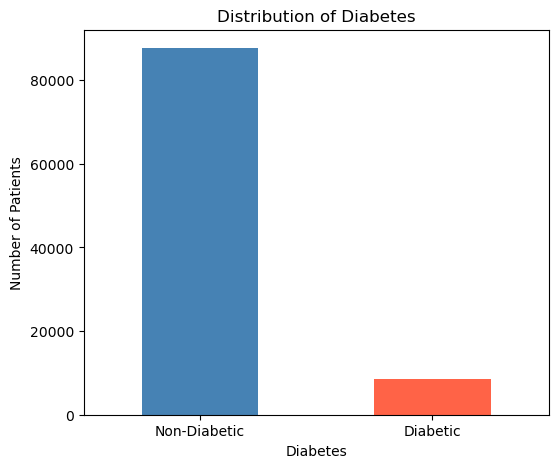

In [90]:
# Bar chart: overall count of diabetic vs non-diabetic patients (shows class imbalance)
plt.figure(figsize=(6,5))

df["diabetes"].value_counts().plot(
    kind="bar",
    color=["steelblue", "tomato"]
)

plt.title("Distribution of Diabetes")
plt.xlabel("Diabetes")
plt.ylabel("Number of Patients")
plt.xticks([0,1], ["Non-Diabetic","Diabetic"], rotation=0)

plt.show()

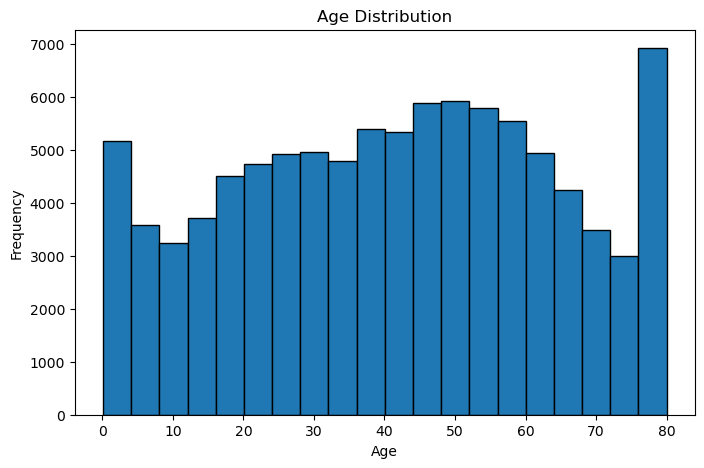

In [91]:
#Age distribution
plt.figure(figsize=(8,5))

plt.hist(
    df["age"],
    bins=20,
    edgecolor="black"
)

plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")

plt.show()

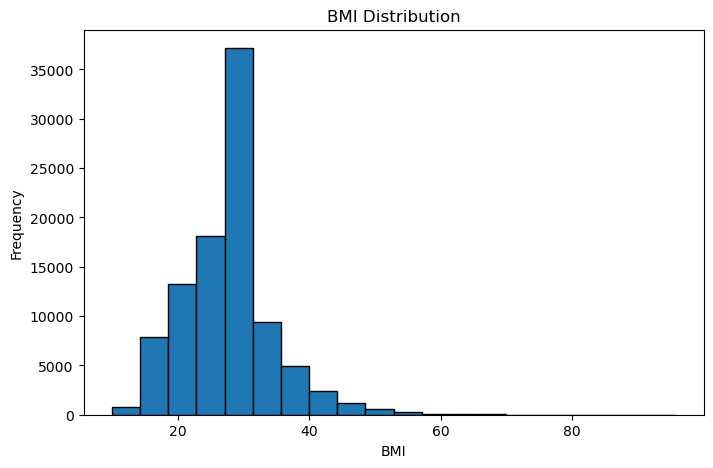

In [92]:
#BMI distribution
plt.figure(figsize=(8,5))

plt.hist(
    df["bmi"],
    bins=20,
    edgecolor="black"
)

plt.title("BMI Distribution")
plt.xlabel("BMI")
plt.ylabel("Frequency")

plt.show()

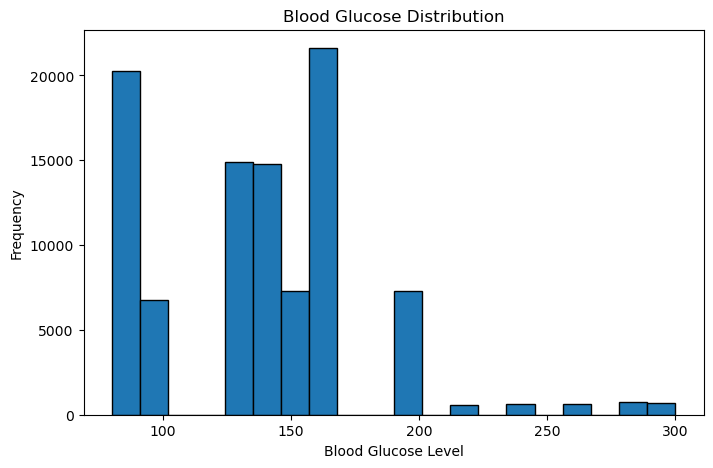

In [93]:
#distribution of blood glucose level across the whole dataset
plt.figure(figsize=(8,5))

plt.hist(
    df["blood_glucose_level"],
    bins=20,
    edgecolor="black"
)

plt.title("Blood Glucose Distribution")
plt.xlabel("Blood Glucose Level")
plt.ylabel("Frequency")

plt.show()

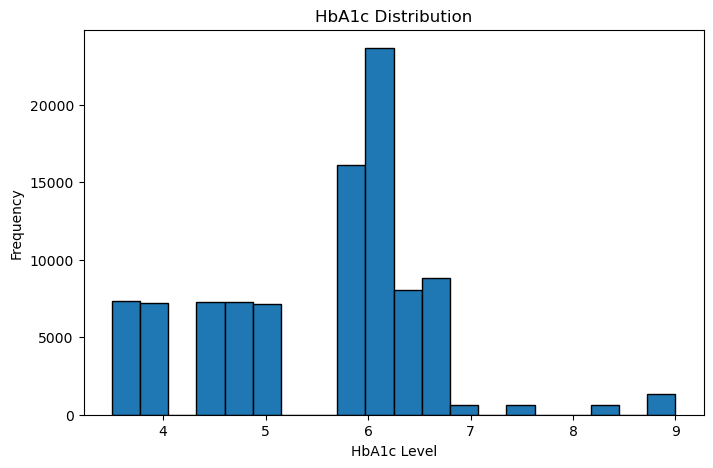

In [94]:
# Histogram: distribution of HbA1c level across the whole dataset
plt.figure(figsize=(8,5))

plt.hist(
    df["HbA1c_level"],
    bins=20,
    edgecolor="black"
)

plt.title("HbA1c Distribution")
plt.xlabel("HbA1c Level")
plt.ylabel("Frequency")

plt.show()

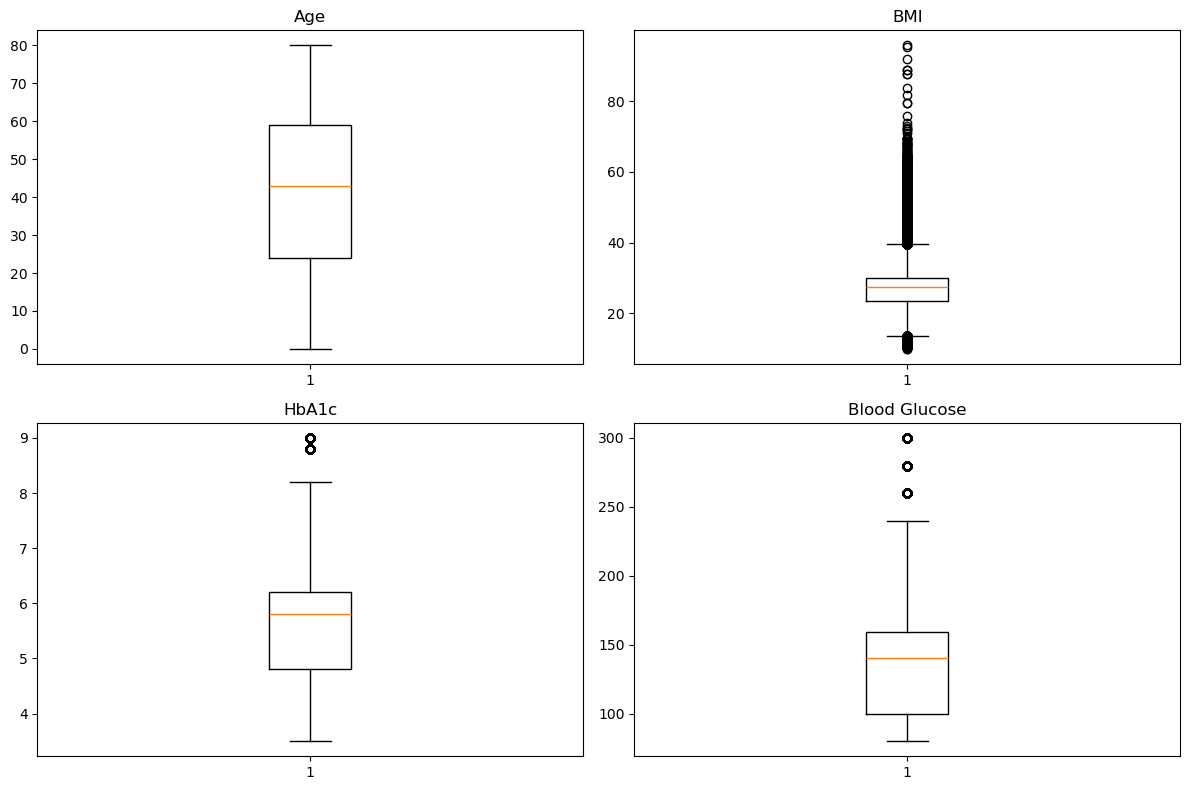

In [95]:
#check spread and outliers for all 4 numeric columns at once
plt.figure(figsize=(12,8))

plt.subplot(2,2,1)
plt.boxplot(df["age"])
plt.title("Age")

plt.subplot(2,2,2)
plt.boxplot(df["bmi"])
plt.title("BMI")

plt.subplot(2,2,3)
plt.boxplot(df["HbA1c_level"])
plt.title("HbA1c")

plt.subplot(2,2,4)
plt.boxplot(df["blood_glucose_level"])
plt.title("Blood Glucose")

plt.tight_layout()
plt.show()

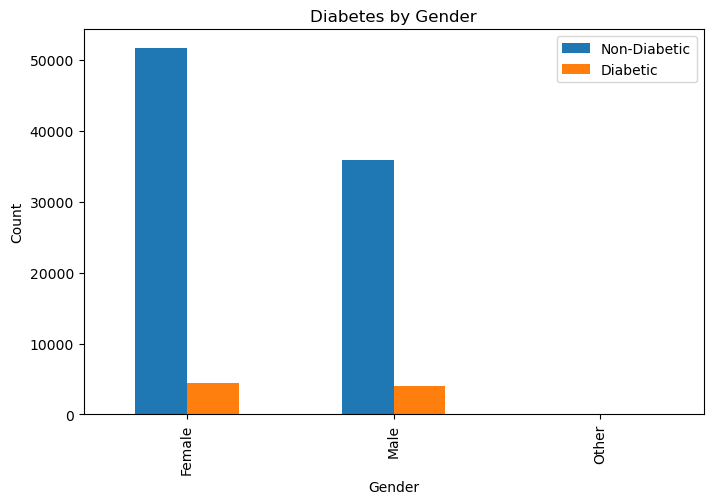

In [96]:
# diabetes count broken down by gender
gender_diabetes = pd.crosstab(
    df["gender"],
    df["diabetes"]
)

gender_diabetes.plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Diabetes by Gender")
plt.xlabel("Gender")
plt.ylabel("Count")
plt.legend(["Non-Diabetic","Diabetic"])

plt.show()

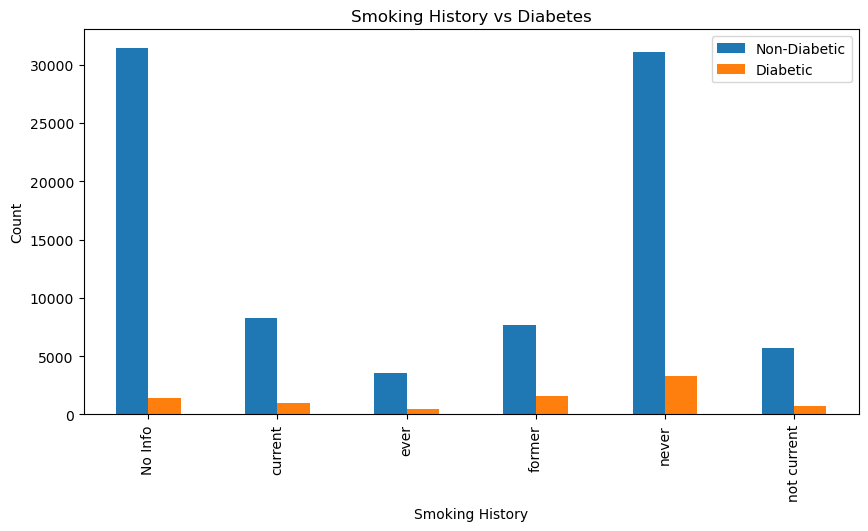

In [97]:
#diabetes count broken down by smoking history
smoking = pd.crosstab(
    df["smoking_history"],
    df["diabetes"]
)

smoking.plot(
    kind="bar",
    figsize=(10,5)
)

plt.title("Smoking History vs Diabetes")
plt.xlabel("Smoking History")
plt.ylabel("Count")
plt.legend(["Non-Diabetic","Diabetic"])

plt.show()

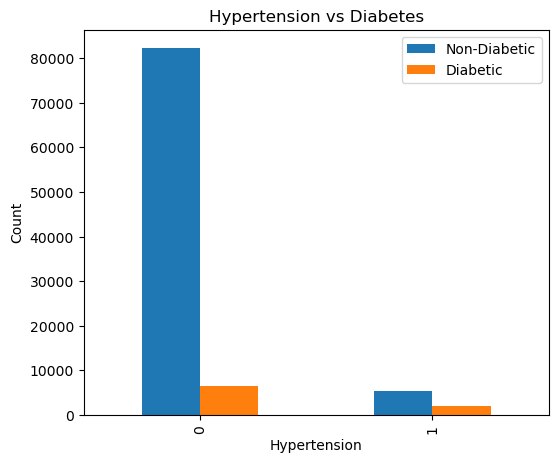

In [98]:
#diabetes count broken down by hypertension status
hypertension = pd.crosstab(
    df["hypertension"],
    df["diabetes"]
)

hypertension.plot(
    kind="bar",
    figsize=(6,5)
)

plt.title("Hypertension vs Diabetes")
plt.xlabel("Hypertension")
plt.ylabel("Count")
plt.legend(["Non-Diabetic","Diabetic"])

plt.show()

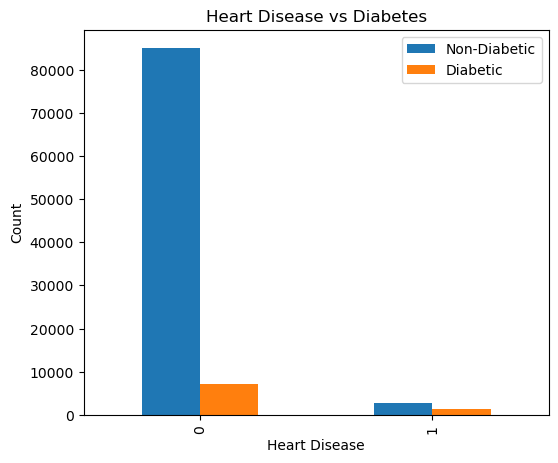

In [99]:
#diabetes broken down by heart disease
heart = pd.crosstab(
    df["heart_disease"],
    df["diabetes"]
)

heart.plot(
    kind="bar",
    figsize=(6,5)
)

plt.title("Heart Disease vs Diabetes")
plt.xlabel("Heart Disease")
plt.ylabel("Count")
plt.legend(["Non-Diabetic","Diabetic"])

plt.show()

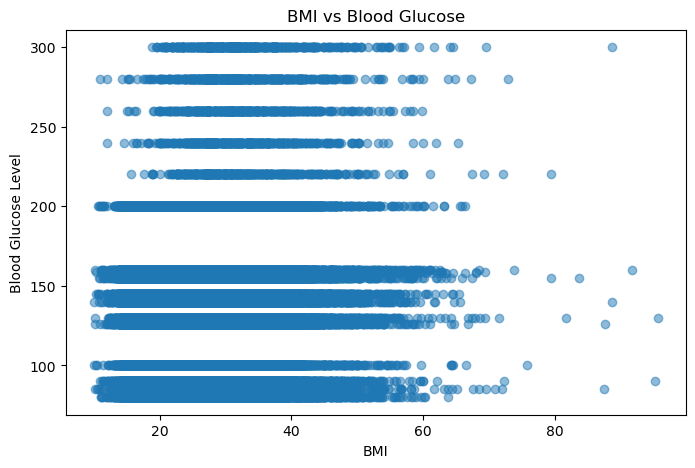

In [100]:
#relationship between BMI and blood glucose level
plt.figure(figsize=(8,5))

plt.scatter(
    df["bmi"],
    df["blood_glucose_level"],
    alpha=0.5
)

plt.title("BMI vs Blood Glucose")
plt.xlabel("BMI")
plt.ylabel("Blood Glucose Level")

plt.show()

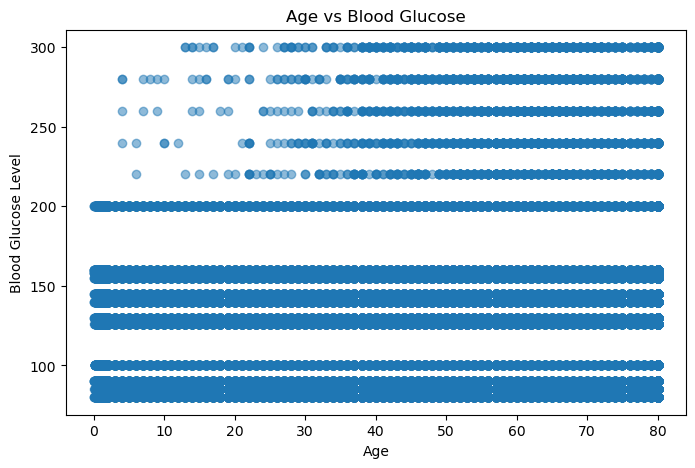

In [101]:
#relationship between age and blood glucose level
plt.figure(figsize=(8,5))

plt.scatter(
    df["age"],
    df["blood_glucose_level"],
    alpha=0.5
)

plt.title("Age vs Blood Glucose")
plt.xlabel("Age")
plt.ylabel("Blood Glucose Level")

plt.show()

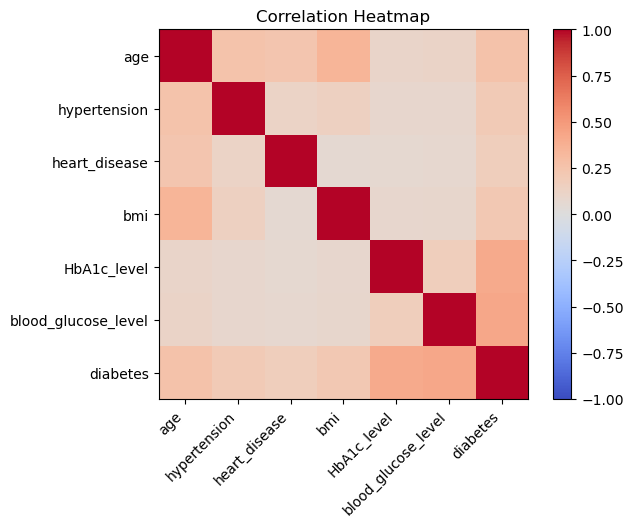

In [102]:
# Correlation heatmap
numeric_cols = ['age','hypertension','heart_disease','bmi','HbA1c_level','blood_glucose_level','diabetes']
corr = df[numeric_cols].corr()
plt.imshow(corr, cmap='coolwarm', vmin=-1, vmax=1)
plt.xticks(range(len(numeric_cols)), numeric_cols, rotation=45, ha='right')
plt.yticks(range(len(numeric_cols)), numeric_cols)
plt.colorbar()
plt.title('Correlation Heatmap')
plt.show()

<Figure size 600x500 with 0 Axes>

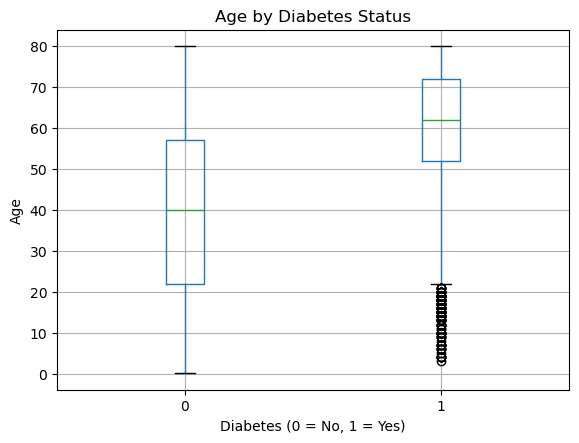

In [103]:
#compare age distribution between diabetic and non-diabetic patients
plt.figure(figsize=(6,5))

df.boxplot(column="age", by="diabetes")

plt.title("Age by Diabetes Status")
plt.suptitle("")
plt.xlabel("Diabetes (0 = No, 1 = Yes)")
plt.ylabel("Age")

plt.show()

<Figure size 600x500 with 0 Axes>

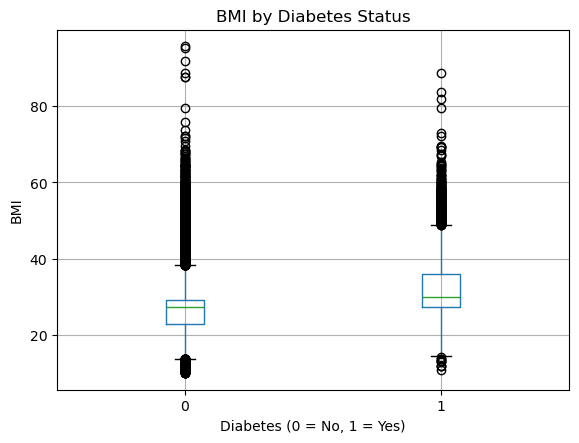

In [104]:
#compare BMI distribution between diabetic and non-diabetic patients
plt.figure(figsize=(6,5))

df.boxplot(column="bmi", by="diabetes")

plt.title("BMI by Diabetes Status")
plt.suptitle("")
plt.xlabel("Diabetes (0 = No, 1 = Yes)")
plt.ylabel("BMI")

plt.show()

<Figure size 600x500 with 0 Axes>

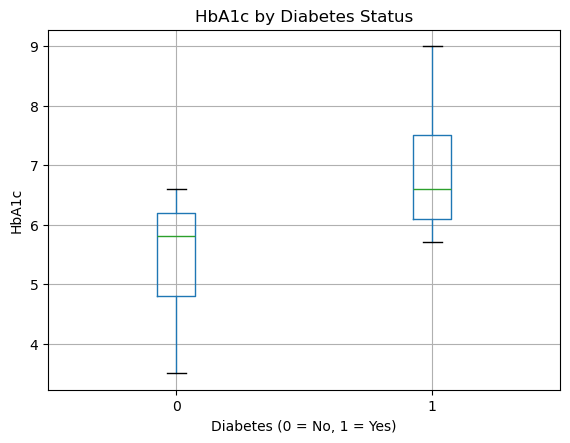

In [105]:
#compare HbA1c distribution between diabetic and non-diabetic patients
plt.figure(figsize=(6,5))

df.boxplot(column="HbA1c_level", by="diabetes")

plt.title("HbA1c by Diabetes Status")
plt.suptitle("")
plt.xlabel("Diabetes (0 = No, 1 = Yes)")
plt.ylabel("HbA1c")

plt.show()

<Figure size 600x500 with 0 Axes>

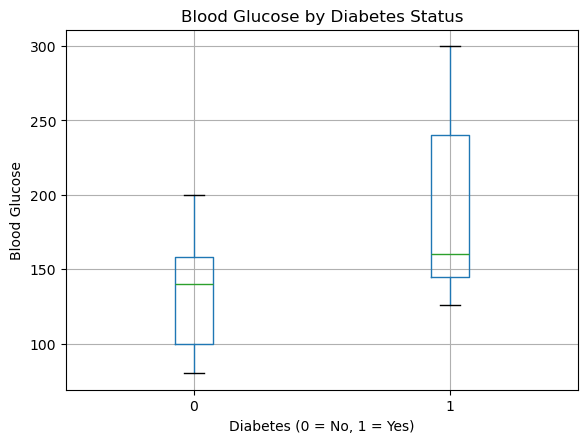

In [106]:
#compare blood glucose distribution between diabetic and non-diabetic patients
plt.figure(figsize=(6,5))

df.boxplot(column="blood_glucose_level", by="diabetes")

plt.title("Blood Glucose by Diabetes Status")
plt.suptitle("")
plt.xlabel("Diabetes (0 = No, 1 = Yes)")
plt.ylabel("Blood Glucose")

plt.show()

In [109]:
encoded_dataframe = pd.get_dummies(
    df,
    columns=["gender", "smoking_history"],
    drop_first=True,
    dtype=int
)
encoded_dataframe.head()

,age,hypertension,heart_disease,bmi,HbA1c_level,blood_glucose_level,diabetes,gender_Male,gender_Other,smoking_history_current,smoking_history_ever,smoking_history_former,smoking_history_never,smoking_history_not current
0,80.0,0,1,25.19,6.6,140,0,0,0,0,0,0,1,0
1,54.0,0,0,27.32,6.6,80,0,0,0,0,0,0,0,0
2,28.0,0,0,27.32,5.7,158,0,1,0,0,0,0,1,0
3,36.0,0,0,23.45,5.0,155,0,0,0,1,0,0,0,0
4,76.0,1,1,20.14,4.8,155,0,1,0,1,0,0,0,0


In [110]:
# Features (Independent variables)
X = encoded_dataframe.drop("diabetes", axis=1)

# Target (Dependent variable)
y = encoded_dataframe["diabetes"]

print(X.shape)
print(y.shape)

(96146, 13)
(96146,)


In [116]:
encoded_dataframe.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 96146 entries, 0 to 96145
Data columns (total 14 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   age                          96146 non-null  float64
 1   hypertension                 96146 non-null  int64  
 2   heart_disease                96146 non-null  int64  
 3   bmi                          96146 non-null  float64
 4   HbA1c_level                  96146 non-null  float64
 5   blood_glucose_level          96146 non-null  int64  
 6   diabetes                     96146 non-null  int64  
 7   gender_Male                  96146 non-null  int64  
 8   gender_Other                 96146 non-null  int64  
 9   smoking_history_current      96146 non-null  int64  
 10  smoking_history_ever         96146 non-null  int64  
 11  smoking_history_former       96146 non-null  int64  
 12  smoking_history_never        96146 non-null  int64  
 13  smoking_history_

In [117]:
encoded_dataframe.describe()

,age,hypertension,heart_disease,bmi,HbA1c_level,blood_glucose_level,diabetes,gender_Male,gender_Other,smoking_history_current,smoking_history_ever,smoking_history_former,smoking_history_never,smoking_history_not current
count,96146.000000,96146.000000,96146.000000,96146.000000,96146.000000,96146.000000,96146.000000,96146.000000,96146.000000,96146.000000,96146.000000,96146.000000,96146.000000,96146.000000
mean,41.794326,0.077601,0.040803,27.321461,5.532609,138.218231,0.088220,0.415691,0.000187,0.095657,0.041583,0.096717,0.357768,0.066222
std,22.462948,0.267544,0.197833,6.767716,1.073232,40.909771,0.283616,0.492843,0.013681,0.294121,0.199634,0.295574,0.479346,0.248671
min,0.080000,0.000000,0.000000,10.010000,3.500000,80.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,24.000000,0.000000,0.000000,23.400000,4.800000,100.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,43.000000,0.000000,0.000000,27.320000,5.800000,140.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,59.000000,0.000000,0.000000,29.860000,6.200000,159.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
max,80.000000,1.000000,1.000000,95.690000,9.000000,300.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [118]:
encoded_dataframe.isnull().sum()

age                            0
hypertension                   0
heart_disease                  0
bmi                            0
HbA1c_level                    0
blood_glucose_level            0
diabetes                       0
gender_Male                    0
gender_Other                   0
smoking_history_current        0
smoking_history_ever           0
smoking_history_former         0
smoking_history_never          0
smoking_history_not current    0
dtype: int64

In [119]:
encoded_dataframe.head()

,age,hypertension,heart_disease,bmi,HbA1c_level,blood_glucose_level,diabetes,gender_Male,gender_Other,smoking_history_current,smoking_history_ever,smoking_history_former,smoking_history_never,smoking_history_not current
0,80.0,0,1,25.19,6.6,140,0,0,0,0,0,0,1,0
1,54.0,0,0,27.32,6.6,80,0,0,0,0,0,0,0,0
2,28.0,0,0,27.32,5.7,158,0,1,0,0,0,0,1,0
3,36.0,0,0,23.45,5.0,155,0,0,0,1,0,0,0,0
4,76.0,1,1,20.14,4.8,155,0,1,0,1,0,0,0,0


In [120]:
encoded_dataframe.to_csv(
    "diabetes_prediction_encoded.csv",
    index=False
)